# Ejercicio 1 – Predicción del rendimiento académico de estudiantes

## Descripción del problema:

El dataset contiene información de estudiantes, donde cada fila representa
un estudiante con variables demográficas, académicas y sociales
(edad, género, apoyo familiar, tiempo de estudio, etc.), junto con su
rendimiento medido por una nota final.

Nuestro objetivo es construir un modelo que clasifique el rendimiento
en tres categorías: "bajo", "medio" y "alto". Esta clasificación puede
apoyar la identificación temprana de estudiantes en riesgo y orientar
acciones de acompañamiento académico.

In [1]:
# Librerías necesarias
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
PROJECT_ROOT = Path.cwd().parent
file_path = PROJECT_ROOT /"data"/"ejercicio01_student-grades.csv"
df = pd.read_csv(file_path)

In [3]:
df.shape

(395, 33)

El dataset contiene 395 registros y 33 variables lo que proporciona una muestra suficiente para explorar patrones generales de rendimiento estudiantil sin dejar de ser manejable en un
entorno de análisis exploratorio.

In [4]:
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Diccionario de variables

| Variable             | Tipo                           | Descripción                                               | Valores posibles / rango                                         |
| -------------------- | ------------------------------ | --------------------------------------------------------- | ---------------------------------------------------------------- |
| school               | Categórica                     | Colegio del estudiante                                    | GP = Gabriel Pereira; MS = Mousinho da Silveira            |
| sex                  | Categórica                     | Sexo del estudiante                                       | F = mujer; M = hombre                                      |
| age                  | Numérica                       | Edad del estudiante                                       | 15 a 22 años aprox.                                        |
| address              | Categórica                     | Tipo de lugar de residencia                               | U = urbano; R = rural                                            |
| famsize              | Categórica                     | Tamaño de la familia                                      | LE3 = ≤ 3; GT3 = > 3 miembros                              |
| Pstatus              | Categórica                     | Estado de convivencia de los padres                       | T = juntos; A = separados                                  |
| Medu                 | Numérica                       | Nivel educativo de la madre                               | 0 = ninguno; 1 = primaria; 2 = 5º–9º; 3 = secundaria; 4 = superior  |
| Fedu                 | Numérica                       | Nivel educativo del padre                                 | Igual codificación que Medu                                |
| Mjob                 | Categórica                     | Ocupación de la madre                                     | teacher, health, services, at_home, other                  |
| Fjob                 | Categórica                     | Ocupación del padre                                       | teacher, health, services, at_home, other                  |
| reason               | Categórica                     | Razón para escoger este colegio                           | home, reputation, course, other                            |
| guardian\| Categórica | Tutor principal del estudiante | mother, father, other                               |                                                                  |
| traveltime           | Numérica                       | Tiempo de desplazamiento casa–colegio                     | 1 = <15 min; 2 = 15–30 min; 3 = 30–60 min; 4 = >1 h        |
| studytime            | Numérica                       | Tiempo de estudio semanal                                 | 1 = <2 h; 2 = 2–5 h; 3 = 5–10 h; 4 = >10 h                 |
| failures             | Numérica                       | Número de asignaturas reprobadas previamente              | n si 1 ≤ n < 3; 4 = 3 o más                                |
| schoolsup            | Categórica                     | Apoyo educativo adicional de la escuela                   | yes / no                                                   |
| famsup               | Categórica                     | Apoyo educativo de la familia                             | yes / no                                                   |
| paid                 | Categórica                     | Clases extra de pago en la materia                        | yes / no                                                   |
| activities           | Categórica                     | Participa en actividades extraescolares                   | yes / no                                                   |
| nursery              | Categórica                     | Asistió a educación preescolar                            | yes / no                                                   |
| higher               | Categórica                     | Desea cursar educación superior                           | yes / no                                                   |
| internet             | Categórica                     | Acceso a internet en casa                                 | yes / no                                                   |
| romantic             | Categórica                     | Tiene relación romántica                                  | yes / no                                                   |
| famrel               | Numérica                       | Calidad de la relación familiar                           | 1 = muy mala, …, 5 = excelente                             |
| freetime             | Numérica                       | Tiempo libre después de clase                             | 1 = muy bajo, …, 5 = muy alto                              |
| goout                | Numérica                       | Frecuencia de salir con amigos                            | 1 = muy bajo, …, 5 = muy alto                              |
| Dalc                 | Numérica                       | Consumo de alcohol entre semana                           | 1 = muy bajo, …, 5 = muy alto                              |
| Walc                 | Numérica                       | Consumo de alcohol en fin de semana                       | 1 = muy bajo, …, 5 = muy alto                              |
| health               | Numérica                       | Estado de salud actual                                    | 1 = muy malo, …, 5 = muy bueno                             |
| absences             | Numérica                       | Número de ausencias a clase                               | 0 a 93                                                     |
| G1                   | Numérica                       | Nota del primer periodo (0–20)                            | 0–20                                                             |
| G2                   | Numérica                       | Nota del segundo periodo (0–20)                           | 0–20 +1                                                          |
| G3                   | Numérica                       | Nota final del curso (0–20), target base para rendimiento | 0–20; muy correlacionada con G1 y G2           |

In [5]:
# Información de tipos y nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

A partir del resumen de `df.info()` se identifican las columnas numéricas y categóricas del dataset. En esta revisión inicial no aparecen valores nulos, lo cual facilita el análisis porque no se pierden registros por información faltante. De todas formas, en el preprocesamiento se mantiene una etapa de imputación dentro del pipeline para que el flujo sea más robusto si en otra versión del dataset aparecieran datos incompletos.

In [6]:
# Estadísticas descriptivas
df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


Se calcularon estadísticas descriptivas básicas para entender la escala y la variabilidad de las variables. En las variables numéricas se revisaron medidas como media, desviación estándar, mínimos, máximos y cuartiles; en las variables categóricas se observaron frecuencias y categorías predominantes.

Este paso ayuda a reconocer patrones iniciales, posibles valores atípicos y diferencias entre variables antes de entrenar los modelos.

In [7]:
# Conteo de nulos
df.isna().sum().sort_values(ascending=False)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

En esta versión del dataset no se encontraron valores nulos. Esto permite avanzar con el análisis sin eliminar filas, aunque se conserva la imputación en el pipeline como buena práctica de modelado.

In [8]:
# Verificamos la variable de rendimiento (nota final)
df['G3'].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

La nota final `G3` se usa como base para construir la variable objetivo. Para que el problema sea de clasificación, se agrupa en tres niveles de rendimiento: `bajo`, `medio` y `alto`.

## Definimos los rangos para clasificar el rendimiento

In [9]:
def convertir_rendimiento(g3):
    if g3 <= 9:
        return 'bajo'
    elif g3 <= 14:
        return 'medio'
    else:
        return 'alto'

df['rendimiento'] = df['G3'].apply(convertir_rendimiento)

df['rendimiento'].value_counts(normalize=True)

rendimiento
medio    0.486076
bajo     0.329114
alto     0.184810
Name: proportion, dtype: float64

# Distribuciones
## - Distribución de la nota final (G3)

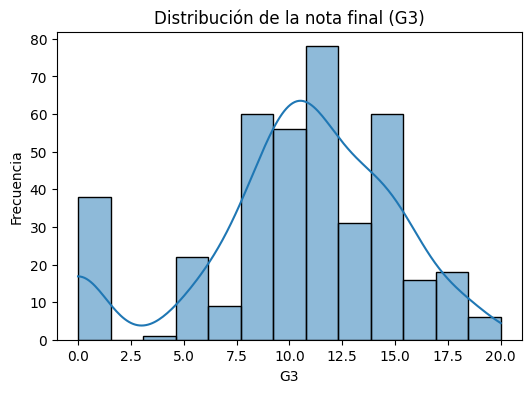

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df['G3'], kde=True)
plt.title('Distribución de la nota final (G3)')
plt.xlabel('G3')
plt.ylabel('Frecuencia')
plt.show()

## - Distribución de la variable objetivo (rendimiento)

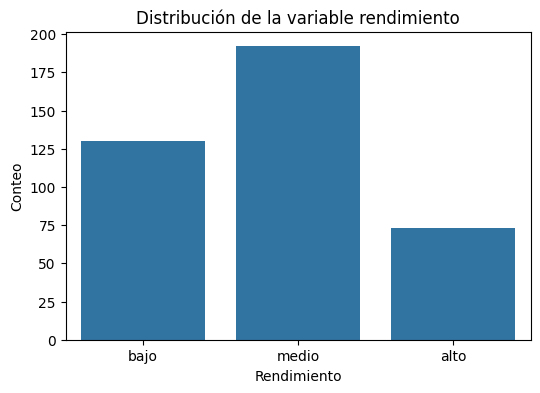

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='rendimiento', data=df,
              order=['bajo','medio','alto'])
plt.title('Distribución de la variable rendimiento')
plt.xlabel('Rendimiento')
plt.ylabel('Conteo')
plt.show()


La mayoría de estudiantes se concentra en la categoría `medio`, mientras que las clases `bajo` y `alto` tienen menos observaciones. Esto muestra un desbalance moderado en la variable objetivo, por lo que las métricas deben interpretarse considerando no solo el Accuracy, sino también Precision, Recall y F1-score.

## - Distribución de edades por nivel de rendimiento

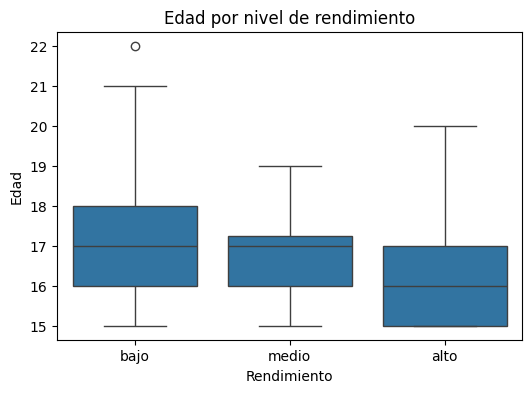

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='rendimiento', y='age', data=df,
            order=['bajo','medio','alto'])
plt.title('Edad por nivel de rendimiento')
plt.xlabel('Rendimiento')
plt.ylabel('Edad')
plt.show()

La distribución por edad no muestra una separación perfecta entre niveles de rendimiento. Aun así, se observan más casos de bajo rendimiento en edades intermedias del grupo, especialmente entre 16 y 18 años. Esta relación debe leerse como una asociación descriptiva, no como una causa directa.

## - Ausencias por rendimiento

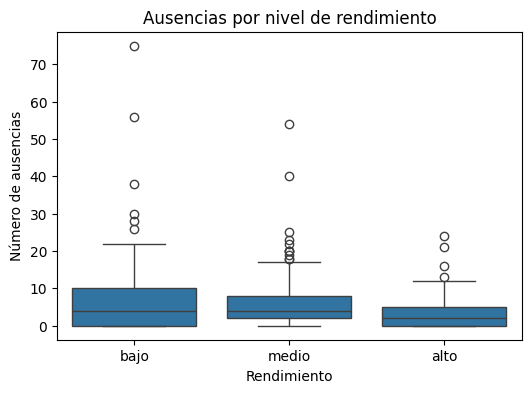

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='rendimiento', y='absences', data=df,
            order=['bajo','medio','alto'])
plt.title('Ausencias por nivel de rendimiento')
plt.xlabel('Rendimiento')
plt.ylabel('Número de ausencias')
plt.show()

El diagrama de caja de `absences` por categoría de `rendimiento` muestra que los estudiantes con rendimiento "bajo" tienden a presentar un número de ausencias mayor y más disperso que quienes se ubican en "medio" o
"alto". Esto respalda la idea de que la inasistencia frecuente puede estar asociada con un peor desempeño académico.

# Análisis de subgrupos
## - Rendimiento por sexo

rendimiento  alto  bajo  medio
sex                           
F              32    75    101
M              41    55     91


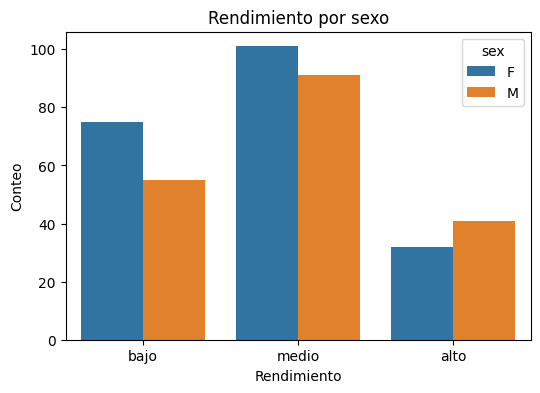

In [14]:
# Conteo absoluto
ct_sex = pd.crosstab(df['sex'], df['rendimiento'])
print(ct_sex)

# Proporción por sexo
ct_sex_prop = pd.crosstab(df['sex'], df['rendimiento'], normalize='index')
ct_sex_prop

plt.figure(figsize=(6,4))
sns.countplot(x='rendimiento', hue='sex', data=df,
              order=['bajo','medio','alto'])
plt.title('Rendimiento por sexo')
plt.xlabel('Rendimiento')
plt.ylabel('Conteo')
plt.show()

rendimiento  alto  bajo  medio
famsup                        
no             31    45     77
yes            42    85    115


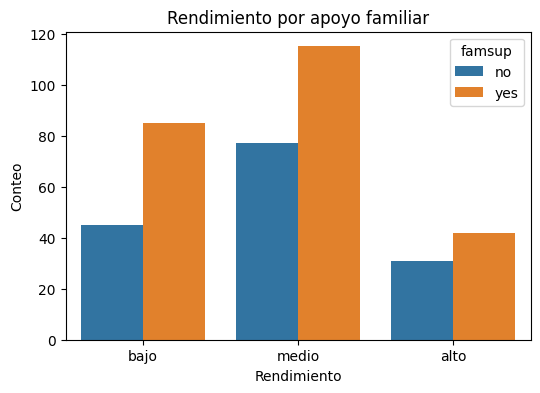

In [15]:
# Conteo absoluto
ct_famsup = pd.crosstab(df['famsup'], df['rendimiento'])
print(ct_famsup)
# Proporción por apoyo familiar
ct_famsup_prop = pd.crosstab(df['famsup'], df['rendimiento'], normalize='index')

plt.figure(figsize=(6,4))
sns.countplot(x='rendimiento', hue='famsup', data=df,
              order=['bajo','medio','alto'])
plt.title('Rendimiento por apoyo familiar')
plt.xlabel('Rendimiento')
plt.ylabel('Conteo')
plt.show()

Al segmentar el rendimiento según la variable `famsup` (apoyo educativo de la familia) se observa que los estudiantes que cuentan con apoyo tienden a presentar una mayor proporción de casos en las categorías
"medio" y "alto", mientras que entre quienes no tienen apoyo la proporción de "bajo" es ligeramente mayor.

## - Rendimiento por estado de convivencia de los padres

rendimiento  alto  bajo  medio
Pstatus                       
A               9    11     21
T              64   119    171


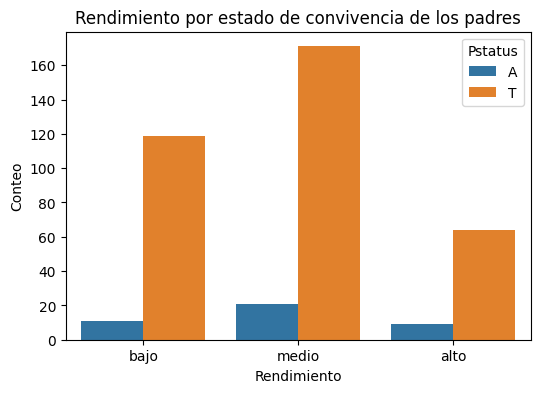

In [16]:
# Conteo absoluto
ct_pstatus = pd.crosstab(df['Pstatus'], df['rendimiento'])
print(ct_pstatus)
# Proporción por estado de convivencia de los padres
ct_pstatus = pd.crosstab(df['Pstatus'], df['rendimiento'], normalize='index')

plt.figure(figsize=(6,4))
sns.countplot(x='rendimiento', hue='Pstatus', data=df,
              order=['bajo','medio','alto'])
plt.title('Rendimiento por estado de convivencia de los padres')
plt.xlabel('Rendimiento')
plt.ylabel('Conteo')
plt.show()

Podemos observar que entre los estudiantes con padres juntos (`Pstatus = T`) la proporción
  de casos en "alto" y "medio" rendimiento es ligeramente mayor. Este patrón sugiere que el estado
de convivencia de los padres podría estar relacionado con el rendimiento académico. Sin embargo, se trata solo de una asociación observacional y no permite concluir causalidad.

# Correlaciones

In [17]:
# Seleccionamos las variables numéricas
numeric_cols = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime',
    'failures', 'famrel', 'freetime', 'goout', 'Dalc',
    'Walc', 'health', 'absences', 'G1', 'G2', 'G3'
]

corr = df[numeric_cols].corr()
corr

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,0.131125,0.117276,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,0.019834,-0.047123,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.002386,-0.012631,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.138325,0.134116,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.196019,-0.253785,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.136047,0.141962,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,-0.077594,-0.113397,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.209001,0.147822,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,0.266994,0.420386,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
Dalc,0.131125,0.019834,0.002386,0.138325,-0.196019,0.136047,-0.077594,0.209001,0.266994,1.000000,0.647544,0.077180,0.111908,-0.094159,-0.064120,-0.054660


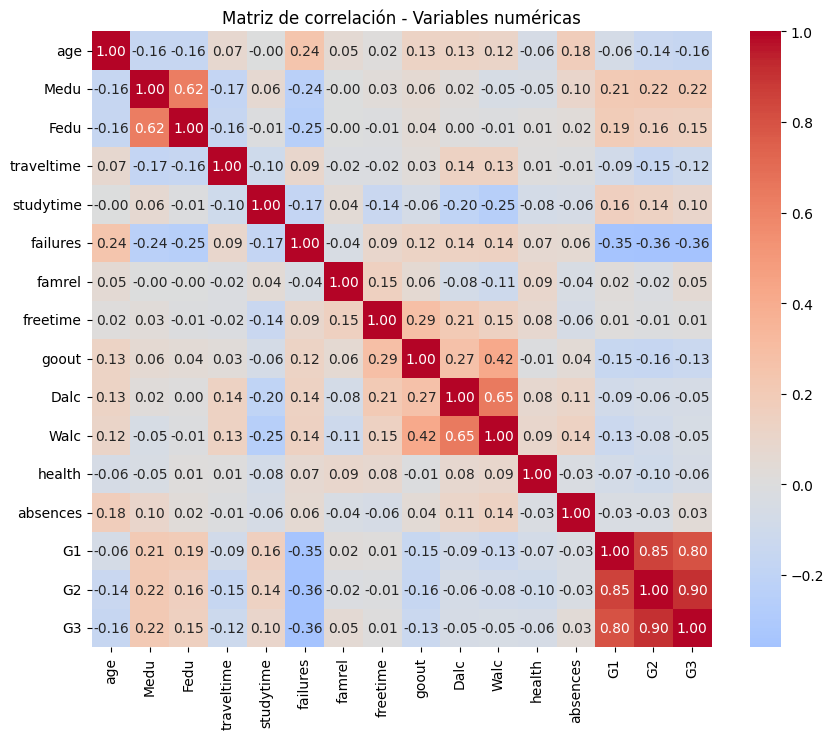

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de correlación - Variables numéricas')
plt.show()

In [19]:
# Vemos las correlaciones concretas con la nota final (G3)
corr_G3 = corr['G3'].sort_values(ascending=False)
corr_G3

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

La matriz de correlación revela que la nota final `G3` presenta una correlación muy alta con las notas de los periodos anteriores `G1` y `G2`, lo cual es esperable porque las tres calificaciones miden el rendimiento
del estudiante a lo largo del mismo curso. Estas relaciones cuantitativas ayudan a identificar qué factores podrían
ser más relevantes para los modelos de clasificación y a interpretar mejor
sus resultados posteriores.

# Preprocesamiento

In [20]:
# Separamos X (features) y y (target)

# y: variable objetivo categórica
y = df['rendimiento']

# X: todas las demás columnas menos G3 y rendimiento
X = df.drop(columns=['rendimiento', 'G3'])

X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,6,5,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,4,5,5
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,10,7,8
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,2,15,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,4,6,10


In [21]:
# Definimos las columnas numéricas y categóricas
numeric_features = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime',
    'failures', 'famrel', 'freetime', 'goout', 'Dalc',
    'Walc', 'health', 'absences', 'G1', 'G2'
]

categorical_features = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'Mjob', 'Fjob', 'reason', 'guardian',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]

# Imputación, estandarización y codificación

In [22]:
# Pipeline para columnas numéricas: imputar + escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para columnas categóricas: imputar + One-Hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer que aplica cada pipeline a su grupo de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Para preparar los datos antes de entrenar los modelos se separó la matriz de características `X` de la variable objetivo categórica `rendimiento`. Las columnas numéricas (edad, educación de los padres, tiempo de estudio,
ausencias, notas parciales, etc.) se procesan mediante un pipeline que aplica imputación por mediana y estandarización con `StandardScaler`, lo cual es importante para algoritmos sensibles a la escala como
Regresión Logística, KNN y SVM.

# Modelo 1-  Regresión logística

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(316, 32) (79, 32)
rendimiento
medio    0.487342
bajo     0.329114
alto     0.183544
Name: proportion, dtype: float64
rendimiento
medio    0.481013
bajo     0.329114
alto     0.189873
Name: proportion, dtype: float64


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Pipeline completo: preprocesamiento + modelo
logreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Entrenamiento
logreg_model.fit(X_train, y_train)

# Predicción
y_pred_logreg = logreg_model.predict(X_test)

# Métricas
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg, average='weighted')
rec_logreg = recall_score(y_test, y_pred_logreg, average='weighted')
f1_logreg = f1_score(y_test, y_pred_logreg, average='weighted')

print("Accuracy:", acc_logreg)
print("Precision:", prec_logreg)
print("Recall:", rec_logreg)
print("F1-score:", f1_logreg)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg))

Accuracy: 0.8607594936708861
Precision: 0.862966889069028
Recall: 0.8607594936708861
F1-score: 0.8603149581474533

Classification Report:

              precision    recall  f1-score   support

        alto       0.87      0.87      0.87        15
        bajo       0.83      0.92      0.87        26
       medio       0.89      0.82      0.85        38

    accuracy                           0.86        79
   macro avg       0.86      0.87      0.86        79
weighted avg       0.86      0.86      0.86        79



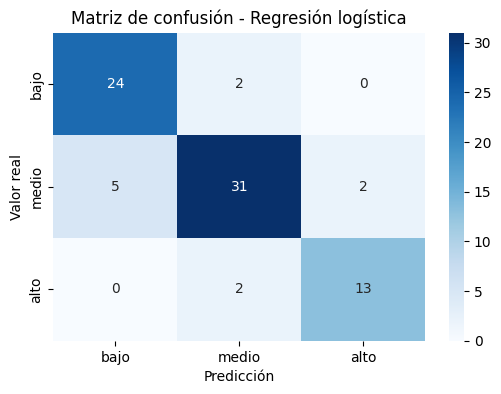

In [25]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=['bajo','medio','alto'])

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bajo','medio','alto'],
            yticklabels=['bajo','medio','alto'])
plt.title('Matriz de confusión - Regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

# Modelo 2 - KNN

KNN clasifica cada estudiante comparándolo con los estudiantes más cercanos en el espacio de características. Es un modelo útil para contrastar con la Regresión Logística porque no parte de una frontera lineal, sino de la cercanía entre perfiles similares. Como depende de distancias, se conserva el mismo preprocesamiento con estandarización de variables numéricas y codificación One-Hot de variables categóricas.

In [26]:
from sklearn.neighbors import KNeighborsClassifier

# Pipeline completo: preprocesamiento + modelo KNN
knn_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Entrenamiento
knn_model.fit(X_train, y_train)

# Prediccion
y_pred_knn = knn_model.predict(X_test)

# Metricas
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average='weighted')
rec_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

print("Accuracy:", acc_knn)
print("Precision:", prec_knn)
print("Recall:", rec_knn)
print("F1-score:", f1_knn)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.6582278481012658
Precision: 0.6827355836849508
Recall: 0.6582278481012658
F1-score: 0.6548581305329818

Classification Report:

              precision    recall  f1-score   support

        alto       0.61      0.73      0.67        15
        bajo       0.81      0.50      0.62        26
       medio       0.62      0.74      0.67        38

    accuracy                           0.66        79
   macro avg       0.68      0.66      0.65        79
weighted avg       0.68      0.66      0.65        79



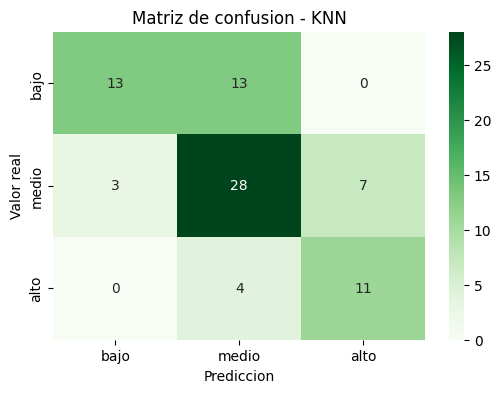

In [27]:
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=['bajo','medio','alto'])

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['bajo','medio','alto'],
            yticklabels=['bajo','medio','alto'])
plt.title('Matriz de confusion - KNN')
plt.xlabel('Prediccion')
plt.ylabel('Valor real')
plt.show()

El modelo KNN obtiene un desempeño menor que la Regresión Logística. Aunque reconoce varios casos de rendimiento medio y alto, confunde una parte importante de los estudiantes de rendimiento bajo con la clase media. Esto sugiere que, en este dataset, la cercanía local entre observaciones no separa las categorías tan bien como la señal lineal capturada por las notas previas y otras variables académicas.

# Modelo 3 - SVM

SVM se usa como tercer modelo supervisado porque permite construir fronteras de decisión más flexibles mediante kernels. En este ejercicio se utiliza un kernel RBF, adecuado cuando puede existir separación no lineal entre niveles de rendimiento. Al igual que KNN, SVM se beneficia de la estandarización previa de las variables numéricas.

In [28]:
from sklearn.svm import SVC

# Pipeline completo: preprocesamiento + modelo SVM
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

# Entrenamiento
svm_model.fit(X_train, y_train)

# Prediccion
y_pred_svm = svm_model.predict(X_test)

# Metricas
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average='weighted')
rec_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print("Accuracy:", acc_svm)
print("Precision:", prec_svm)
print("Recall:", rec_svm)
print("F1-score:", f1_svm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.8227848101265823
Precision: 0.8367692759692297
Recall: 0.8227848101265823
F1-score: 0.8197390756098745

Classification Report:

              precision    recall  f1-score   support

        alto       0.93      0.87      0.90        15
        bajo       0.89      0.65      0.76        26
       medio       0.76      0.92      0.83        38

    accuracy                           0.82        79
   macro avg       0.86      0.81      0.83        79
weighted avg       0.84      0.82      0.82        79



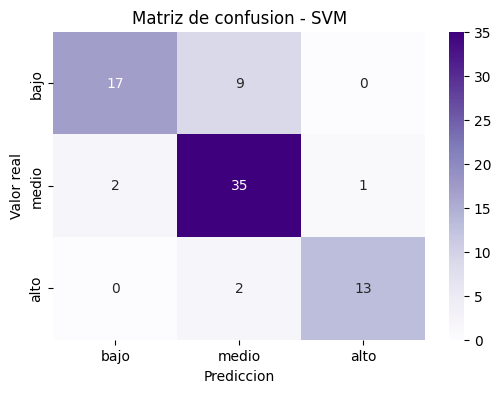

In [29]:
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=['bajo','medio','alto'])

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['bajo','medio','alto'],
            yticklabels=['bajo','medio','alto'])
plt.title('Matriz de confusion - SVM')
plt.xlabel('Prediccion')
plt.ylabel('Valor real')
plt.show()

SVM alcanza un rendimiento competitivo y queda por encima de KNN, aunque no supera a la Regresión Logística. Su matriz de confusión muestra un buen reconocimiento de la clase alta y de la clase media, pero presenta más dificultad para separar algunos casos de rendimiento bajo, que son clasificados como rendimiento medio.

# Visualización con PCA

In [30]:
from sklearn.decomposition import PCA

# 1) Ajustar preprocessor solo con datos X (sin el clasificador)
X_preprocessed = preprocessor.fit_transform(X)

# 2) PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_preprocessed)

# 3) DataFrame para graficar
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['rendimiento'] = y.values

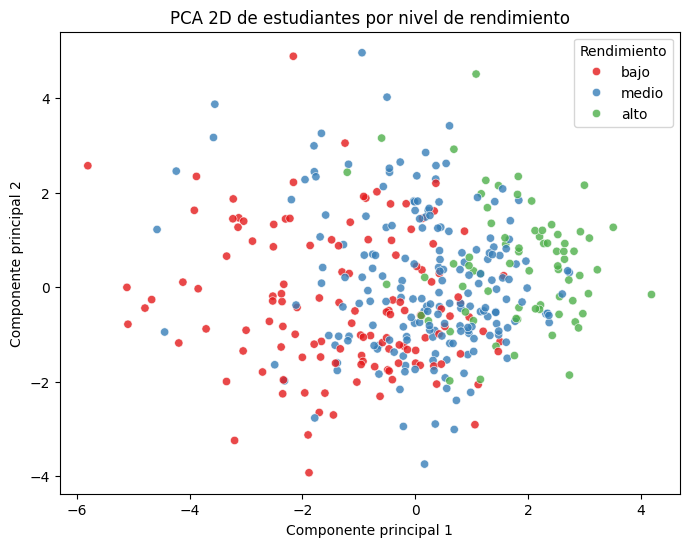

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='rendimiento',
    hue_order=['bajo','medio','alto'],
    palette='Set1',
    alpha=0.8
)
plt.title('PCA 2D de estudiantes por nivel de rendimiento')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Rendimiento')
plt.show()

En la visualización se observa que los estudiantes de las tres categorías de rendimiento (`bajo`, `medio` y `alto`) comparten una región común del espacio y presentan solapamiento. También se ven zonas donde los casos de rendimiento alto tienden a ubicarse hacia valores más altos del primer componente, mientras que varios casos de rendimiento bajo aparecen hacia la parte izquierda del plano.

Esto indica que los datos sí tienen estructura útil para la clasificación, pero no una separación perfecta. Por eso es razonable que los modelos cometan errores, especialmente entre categorías cercanas como `bajo` y `medio`.

# Tabla de métricas globales

| Modelo | Accuracy | Precision | Recall | F1-score |
|--------|----------|-----------|--------|----------|
| Regresión Logística | 0.86 | 0.86 | 0.86 | 0.86 |
| KNN | 0.66 | 0.68 | 0.66 | 0.65 |
| SVM | 0.82 | 0.84 | 0.82 | 0.82 |

In [32]:
metricas_globales = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'KNN', 'SVM'],
    'Accuracy': [acc_logreg, acc_knn, acc_svm],
    'Precision': [prec_logreg, prec_knn, prec_svm],
    'Recall': [rec_logreg, rec_knn, rec_svm],
    'F1-score': [f1_logreg, f1_knn, f1_svm]
})

metricas_globales.round(2)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.86,0.86,0.86,0.86
1,KNN,0.66,0.68,0.66,0.65
2,SVM,0.82,0.84,0.82,0.82


# Justificación de los algoritmos
### Regresión Logística
Se utiliza como modelo base porque está diseñada para problemas de clasificación y permite estimar la probabilidad de pertenencia a cada categoría de rendimiento. Es adecuada aquí porque el dataset es tabular y las notas previas (`G1`, `G2`) generan una señal bastante lineal. Además,es un modelo interpretable ya que sus coeficientes permiten entender qué
variables aumentan o disminuyen la probabilidad de estar en cada nivel de rendimiento. Su limitación principal es que puede no capturar bien relaciones fuertemente no lineales entre las variables.

### K-Nearest Neighbors (KNN)
KNN clasifica a cada estudiante según la clase predominante entre sus vecinos más cercanos, lo que tiene sentido en este contexto porque estudiantes con perfiles similares suelen presentar niveles de rendimiento parecidos. No impone una forma lineal fija y puede capturar patrones locales en los datos. Sin embargo, es muy sensible a la escala de las
variables y a la alta dimensionalidad que aparece después del One-Hot Encoding, lo que en este ejercicio se refleja en un desempeño inferior al de la Regresión Logística y SVM.

### Support Vector Machine (SVM)
SVM se incluyó como tercer modelo porque permite construir fronteras de decisión no lineales mediante kernels, en este caso RBF, lo que puede ser útil cuando hay relaciones complejas entre las variables y las clases de rendimiento. Funciona bien en espacios de alta dimensionalidad y obtuvo un desempeño competitivo en este ejercicio. No obstante, es menos interpretable que la Regresión Logística y su calidad depende de la elección de hiperparámetros, por lo que requiere un proceso de ajuste adicional.

# Interpretación de resultados

La Regresión Logística fue el modelo con mejor desempeño global, con un Accuracy y F1-score ponderado de 0.86. Este resultado indica que, para este conjunto de datos, las variables académicas disponibles, especialmente `G1` y `G2`, entregan una señal fuerte y relativamente lineal para clasificar el rendimiento final.

SVM también obtuvo un desempeño alto, con Accuracy de 0.82 y F1-score de 0.82, por lo que funciona como una alternativa competitiva cuando se desea capturar fronteras no lineales. Sin embargo, en esta partición de prueba no mejora a la Regresión Logística.

KNN fue el modelo con menor desempeño, con Accuracy de 0.66 y F1-score de 0.65. Su resultado puede explicarse por la mezcla de variables numéricas y categóricas codificadas, la dimensionalidad generada por One-Hot Encoding y el solapamiento observado en PCA.

# Conclusiones

El ejercicio muestra que sí es posible aproximarse al rendimiento académico de un estudiante usando
datos disponibles sobre su trayectoria escolar, hábitos y contexto. Sin embargo, también deja claro
que el rendimiento no depende de una sola variable ni puede entenderse únicamente como un resultado
numérico. Detrás de cada registro hay condiciones familiares, rutinas de estudio, ausencias, apoyos
recibidos y experiencias personales que influyen en el proceso educativo.

El modelo con mejor desempeño fue la Regresión Logística, con Accuracy y F1-score ponderado de 0.86.
Este resultado es importante porque demuestra que, para este conjunto de datos, un modelo relativamente
sencillo e interpretable puede funcionar mejor que alternativas más complejas. No siempre el modelo más
sofisticado es el más conveniente; en un contexto educativo también importa poder explicar por qué se
produce una predicción y qué señales están influyendo en ella.

Las variables más fuertes fueron las notas previas `G1` y `G2`, lo cual tiene sentido: el desempeño
anterior suele ser una señal directa del desempeño final. Aun así, variables como las ausencias, los
fallos previos y el tiempo de estudio aportan información adicional que ayuda a comprender mejor el
perfil de cada estudiante. Esto sugiere que el modelo no solo aprende una calificación, sino una
combinación de factores académicos y de contexto.

La comparación entre modelos también fue útil. SVM obtuvo un rendimiento competitivo, pero no superó a
la Regresión Logística. KNN tuvo más dificultades, especialmente al separar estudiantes de rendimiento
bajo y medio. Esto coincide con la visualización mediante PCA, donde se observa que las categorías no
forman grupos totalmente separados. En la práctica, esto es esperable: el rendimiento académico suele
moverse en una escala gradual, y no siempre existe una frontera clara entre un estudiante de nivel bajo
y uno de nivel medio.

Desde una perspectiva humana y ética, este tipo de modelo debe usarse como una herramienta de apoyo,
no como una forma de etiquetar estudiantes. Una predicción de bajo rendimiento no debería interpretarse
como una sentencia, sino como una alerta para conversar, acompañar y ofrecer refuerzos a tiempo. El valor
real del análisis está en ayudar a tomar mejores decisiones pedagógicas, no en reemplazar el criterio de
docentes, tutores o instituciones.

Como trabajo futuro, sería recomendable probar validación cruzada, ajustar hiperparámetros y evaluar el
modelo con nuevos datos para comprobar si mantiene su desempeño. También sería útil construir una versión
de alerta temprana que no dependa tanto de `G1` y `G2`, especialmente si se quiere intervenir antes de que
el estudiante ya tenga varias calificaciones acumuladas.